In [1]:
from experiments.dj.posterior_tables import SBVGPConfig
from experiments.dj.sysident_tables import SIConfig
from experiments.dj.result_tables import (
    SBVGPResult2,
    SIResult,
    FlowPriorResult,
    SBVGPAdaptedResult,
    FPSamplesConfig,
    FPSamples,
    MLPCondSamples2,
    AdaptPriorResult,
    LikelihoodResult,
)
from experiments.dj.dataloader_tables import DataLoaderConfig


from task_transfer.utils.insilico_stimuli import generate_gabors
from task_transfer.ml_lib.data_loading import build_dataloaders

from task_transfer.evaluation.evaluate_generative_model import (
    compute_logl,
    compute_haefner_logl_i_cond_x,
    visualize_conditional_features,
)

import torch
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

from task_transfer.sampling_models.plotting import plot_cohen_task, plot_haefner_model


from task_transfer.utils.model_utils import build_haefner_model

import experiments.orientation_discrimination.haefner_model.configs as cfg

from pathlib import Path

import pickle


import numpy as np
from task_transfer.utils.math_utils import cos2_von_mises

torch.manual_seed(42)

[2024-09-17 08:30:54,106][INFO]: Connecting sshrinivasan@134.76.19.44:3306
[2024-09-17 08:30:54,119][INFO]: Connected sshrinivasan@134.76.19.44:3306
/usr/local/lib/python3.8/dist-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: libtorch_cuda_cu.so: cannot open shared object file: No such file or directory
  warn(f"Failed to load image Python extension: {e}")


In [2]:
dataloader_config1 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader1, val_loader1, test_loader1 = build_dataloaders(
    data_fname=dataloader_config1["data_fname"],
    train_prop=dataloader_config1["train_prop"],
    val_prop=dataloader_config1["val_prop"],
    batch_size=dataloader_config1["batch_size"],
)

dataloader_config2 = {
    "data_fname": "/src/project/data/synthetic/haefner_2afc/original_haefner_2afc_task_1_dataset.pkl",
    "train_prop": 0.7,
    "val_prop": 0.2,
    "batch_size": 128,
}
train_loader2, val_loader2, test_loader2 = build_dataloaders(
    data_fname=dataloader_config2["data_fname"],
    train_prop=dataloader_config2["train_prop"],
    val_prop=dataloader_config2["val_prop"],
    batch_size=dataloader_config2["batch_size"],
)

dl1_id = "260a5ea8175f75eaef132f42873ad14a"
dl2_id = "9ef3ae6fea33eba634d928a88b866836"

In [3]:
SBVGPResult2 & f"dl_id='{dl2_id}'"

sbvp_id,sbvp_trainer_id,fp_samples_id from FlowPriorResult,dl_id from FlowPriorResult and DataLoaderConfig,trainer_id from FlowPriorResult and FPTrainerConfig,data_seed,n_samples,mlpcond_samples_id from LikelihoodResult,ll_trainer_id from LikelihoodResult and LLTrainerConfig,"train_ll_mean mean per dimension, per sample, in nats",train_ll_sem standard error of the mean,val_ll_mean,val_ll_sem,test_ll_mean,test_ll_sem,"train_ll_mean_sample mean per dimension, per sample, in nats",train_ll_sem_sample standard error of the mean,val_ll_mean_sample,val_ll_sem_sample,test_ll_mean_sample,test_ll_sem_sample,tracker_output,eval_output,model


In [4]:
metric = "val_ll_mean"
limit = 1
download_path = "/tmp"

si_restriction1 = f"dl_id = '{dl1_id}'"
si1 = (SIResult & si_restriction1).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1 = f"dl_id = '{dl1_id}'"
sbv_restriction1_50k = sbv_restriction1 + " and n_samples = 50000"
sbv1_50k = (SBVGPResult2 & sbv_restriction1_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_30k = sbv_restriction1 + " and n_samples = 30000"
sbv1_30k = (SBVGPResult2 & sbv_restriction1_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_20k = sbv_restriction1 + " and n_samples = 20000"
sbv1_20k = (SBVGPResult2 & sbv_restriction1_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction1_10k = sbv_restriction1 + " and n_samples = 10000"
sbv1_10k = (SBVGPResult2 & sbv_restriction1_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si1_model = torch.load(si1["model"], map_location="cpu")
sbv1_50k_model = torch.load(sbv1_50k["model"], map_location="cpu")
sbv1_30k_model = torch.load(sbv1_30k["model"], map_location="cpu")
sbv1_20k_model = torch.load(sbv1_20k["model"], map_location="cpu")
sbv1_10k_model = torch.load(sbv1_10k["model"], map_location="cpu")

sbv1_prior = (
    FlowPriorResult
    & {
        "dl_id": sbv1_50k["dl_id"],
        "trainer_id": sbv1_50k["trainer_id"],
        "fp_id": sbv1_50k["fp_samples_id"],
    }
).fetch1(download_path=download_path)
sbv1_prior_model = torch.load(
    sbv1_prior["model"],
)

sbv1_likelihood = (
    LikelihoodResult
    & {
        "dl_id": sbv1_50k["dl_id"],
        "trainer_id": sbv1_50k["ll_trainer_id"],
        "ll_id": sbv1_50k["mlpcond_samples_id"],
    }
).fetch1(download_path=download_path)
sbv1_likelihood_model = torch.load(sbv1_likelihood["model"], map_location="cpu")

In [5]:
si_restriction2 = f"dl_id = '{dl2_id}'"

si2 = (SIResult & si_restriction2).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2 = f"alt_dl_id = '{dl2_id}'"
sbv_restriction2_50k = sbv_restriction2 + " and n_samples = 50000"
sbv2_50k = (SBVGPAdaptedResult & sbv_restriction2_50k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_30k = sbv_restriction2 + " and n_samples = 30000"
sbv2_30k = (SBVGPAdaptedResult & sbv_restriction2_30k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_20k = sbv_restriction2 + " and n_samples = 20000"
sbv2_20k = (SBVGPAdaptedResult & sbv_restriction2_20k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

sbv_restriction2_10k = sbv_restriction2 + " and n_samples = 10000"
sbv2_10k = (SBVGPAdaptedResult & sbv_restriction2_10k).fetch(
    download_path=download_path, order_by=f"{metric} DESC", limit=limit, as_dict=True
)[0]

si2_model = torch.load(si2["model"], map_location="cpu")
sbv2_50k_model = torch.load(sbv2_50k["model"], map_location="cpu")
sbv2_30k_model = torch.load(sbv2_30k["model"], map_location="cpu")
sbv2_20k_model = torch.load(sbv2_20k["model"], map_location="cpu")
sbv2_10k_model = torch.load(sbv2_10k["model"], map_location="cpu")

sbv2_gen = (
    AdaptPriorResult
    & {
        "prior_fp_id": sbv2_50k["prior_fp_id"],
        "prior_trainer_id": sbv2_50k["prior_trainer_id"],
        "dl_id": sbv2_50k["alt_dl_id"],
        "seed": sbv2_50k["data_seed"],
    }
).fetch1(download_path=download_path)
sbv2_gen_model = torch.load(sbv2_gen["model"], map_location="cpu")
sbv2_prior_model = sbv2_gen_model.prior
sbv2_likelihood_model = sbv2_gen_model.conditional

In [6]:
image_dim = 1
response_dim = 0
reduction = "mean"
uncertainty = "none"
normalize = "per_dim"
unit = "bits"

evaluate_prior_model = lambda model, data_loader: compute_logl(
    model=model,
    data_loader=data_loader,
    data_dim=response_dim,
    cond_dim=None,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

evaluate_pred_model = lambda model, data_loader: compute_logl(
    model,
    data_loader,
    data_dim=response_dim,
    cond_dim=image_dim,
    reduction=reduction,
    uncertainty=uncertainty,
    normalize=normalize,
    unit=unit,
)

In [7]:
train_sbv1_prior_data1 = evaluate_prior_model(
    model=sbv1_prior_model,
    data_loader=train_loader1,
)[0]
val_sbv1_prior_data1 = evaluate_prior_model(
    model=sbv1_prior_model,
    data_loader=val_loader1,
)[0]
test_sbv1_prior_data1 = evaluate_prior_model(
    model=sbv1_prior_model,
    data_loader=test_loader1,
)[0]

In [8]:
train_si1_data1 = evaluate_pred_model(si1_model, train_loader1)[0]
val_si1_data1 = evaluate_pred_model(si1_model, val_loader1)[0]
test_si1_data1 = evaluate_pred_model(si1_model, test_loader1)[0]

train_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, train_loader1)[0]
val_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, val_loader1)[0]
test_sbv1_50k_data1 = evaluate_pred_model(sbv1_50k_model, test_loader1)[0]

train_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, train_loader1)[0]
val_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, val_loader1)[0]
test_sbv1_30k_data1 = evaluate_pred_model(sbv1_30k_model, test_loader1)[0]

train_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, train_loader1)[0]
val_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, val_loader1)[0]
test_sbv1_20k_data1 = evaluate_pred_model(sbv1_20k_model, test_loader1)[0]

train_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, train_loader1)[0]
val_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, val_loader1)[0]
test_sbv1_10k_data1 = evaluate_pred_model(sbv1_10k_model, test_loader1)[0]

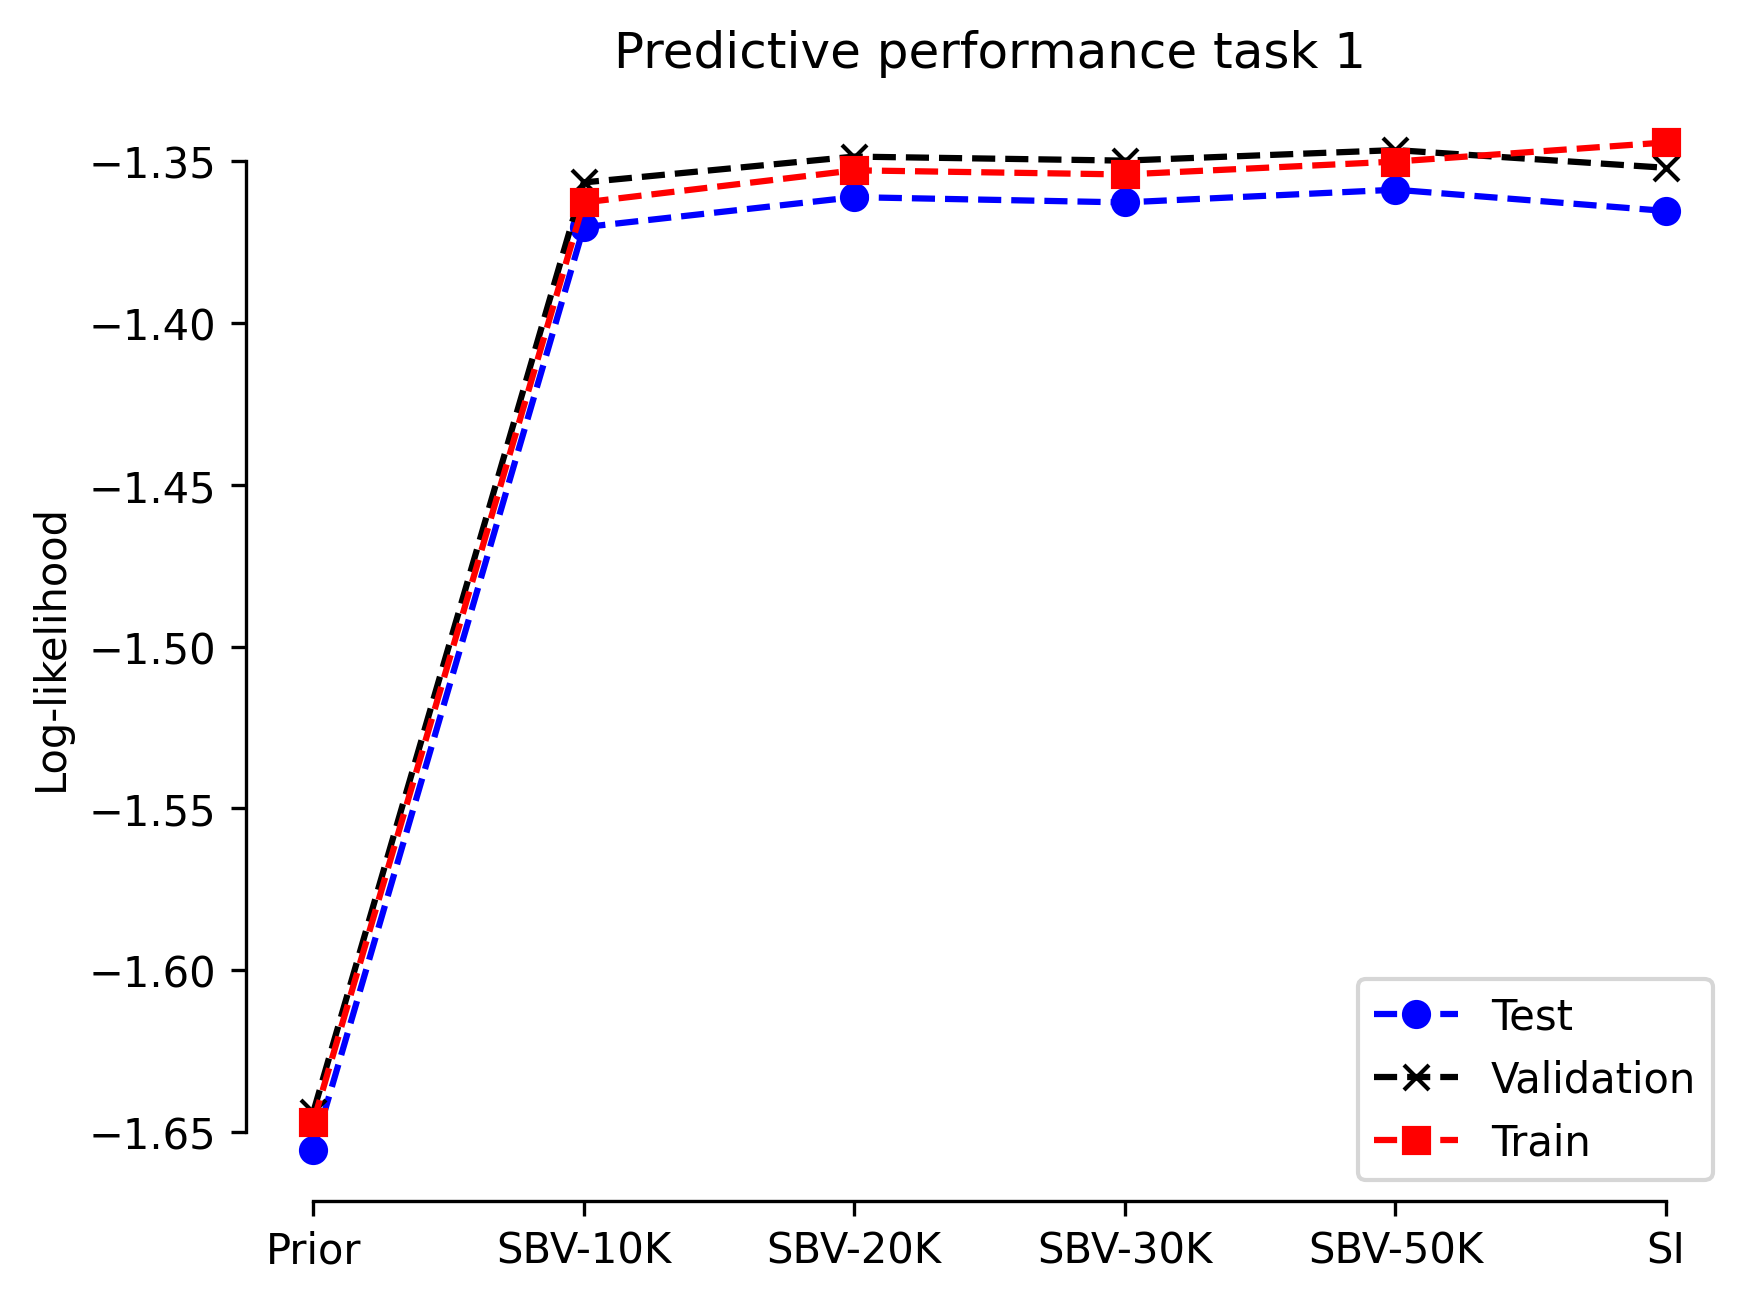

In [9]:
train_metrics_data1 = [
    train_si1_data1,
    train_sbv1_50k_data1,
    train_sbv1_30k_data1,
    train_sbv1_20k_data1,
    train_sbv1_10k_data1,
    train_sbv1_prior_data1,
]
val_metrics_data1 = [
    val_si1_data1,
    val_sbv1_50k_data1,
    val_sbv1_30k_data1,
    val_sbv1_20k_data1,
    val_sbv1_10k_data1,
    val_sbv1_prior_data1,
]
test_metrics_data1 = [
    test_si1_data1,
    test_sbv1_50k_data1,
    test_sbv1_30k_data1,
    test_sbv1_20k_data1,
    test_sbv1_10k_data1,
    test_sbv1_prior_data1,
]

# Update the x-axis labels
x = ["SI", "SBV-50K", "SBV-30K", "SBV-20K", "SBV-10K", "Prior"]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1],
    test_metrics_data1[::-1],
    color="blue",
    marker="o",
    linestyle="--",
    label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data1[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1],
    train_metrics_data1[::-1],
    color="red",
    marker="s",
    linestyle="--",
    label="Train",
)


sns.despine(ax=ax, trim=True)
ax.set_ylabel("Log-likelihood")
ax.set_title("Predictive performance task 1")
ax.legend()
plt.show()

In [10]:
train_si2_data2 = evaluate_pred_model(si2_model, train_loader2)[0]
val_si2_data2 = evaluate_pred_model(si2_model, val_loader2)[0]
test_si2_data2 = evaluate_pred_model(si2_model, test_loader2)[0]

train_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_50k_model, train_loader2)[0]
val_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, val_loader2)[0]
test_sbv2_50k_data2 = evaluate_pred_model(sbv2_50k_model, test_loader2)[0]

train_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, train_loader2)[0]
val_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, val_loader2)[0]
test_sbv2_30k_data2 = evaluate_pred_model(sbv2_30k_model, test_loader2)[0]

train_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, train_loader2)[0]
val_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, val_loader2)[0]
test_sbv2_20k_data2 = evaluate_pred_model(sbv2_20k_model, test_loader2)[0]

train_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, train_loader2)[0]
val_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, val_loader2)[0]
test_sbv2_10k_data2 = evaluate_pred_model(sbv2_10k_model, test_loader2)[0]

train_si1_data2 = evaluate_pred_model(si1_model, train_loader2)[0]
val_si1_data2 = evaluate_pred_model(si1_model, val_loader2)[0]
test_si1_data2 = evaluate_pred_model(si1_model, test_loader2)[0]

train_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, train_loader2)[0]
val_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, val_loader2)[0]
test_sbv1_50k_data2 = evaluate_pred_model(sbv1_50k_model, test_loader2)[0]

train_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, train_loader2)[0]
val_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, val_loader2)[0]
test_sbv1_30k_data2 = evaluate_pred_model(sbv1_30k_model, test_loader2)[0]

train_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, train_loader2)[0]
val_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, val_loader2)[0]
test_sbv1_20k_data2 = evaluate_pred_model(sbv1_20k_model, test_loader2)[0]

train_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, train_loader2)[0]
val_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, val_loader2)[0]
test_sbv1_10k_data2 = evaluate_pred_model(sbv1_10k_model, test_loader2)[0]

train_sbv2_prior_data2 = evaluate_prior_model(sbv2_prior_model, train_loader2)[0]
val_sbv2_prior_data2 = evaluate_prior_model(sbv2_prior_model, val_loader2)[0]
test_sbv2_prior_data2 = evaluate_prior_model(sbv2_prior_model, test_loader2)[0]

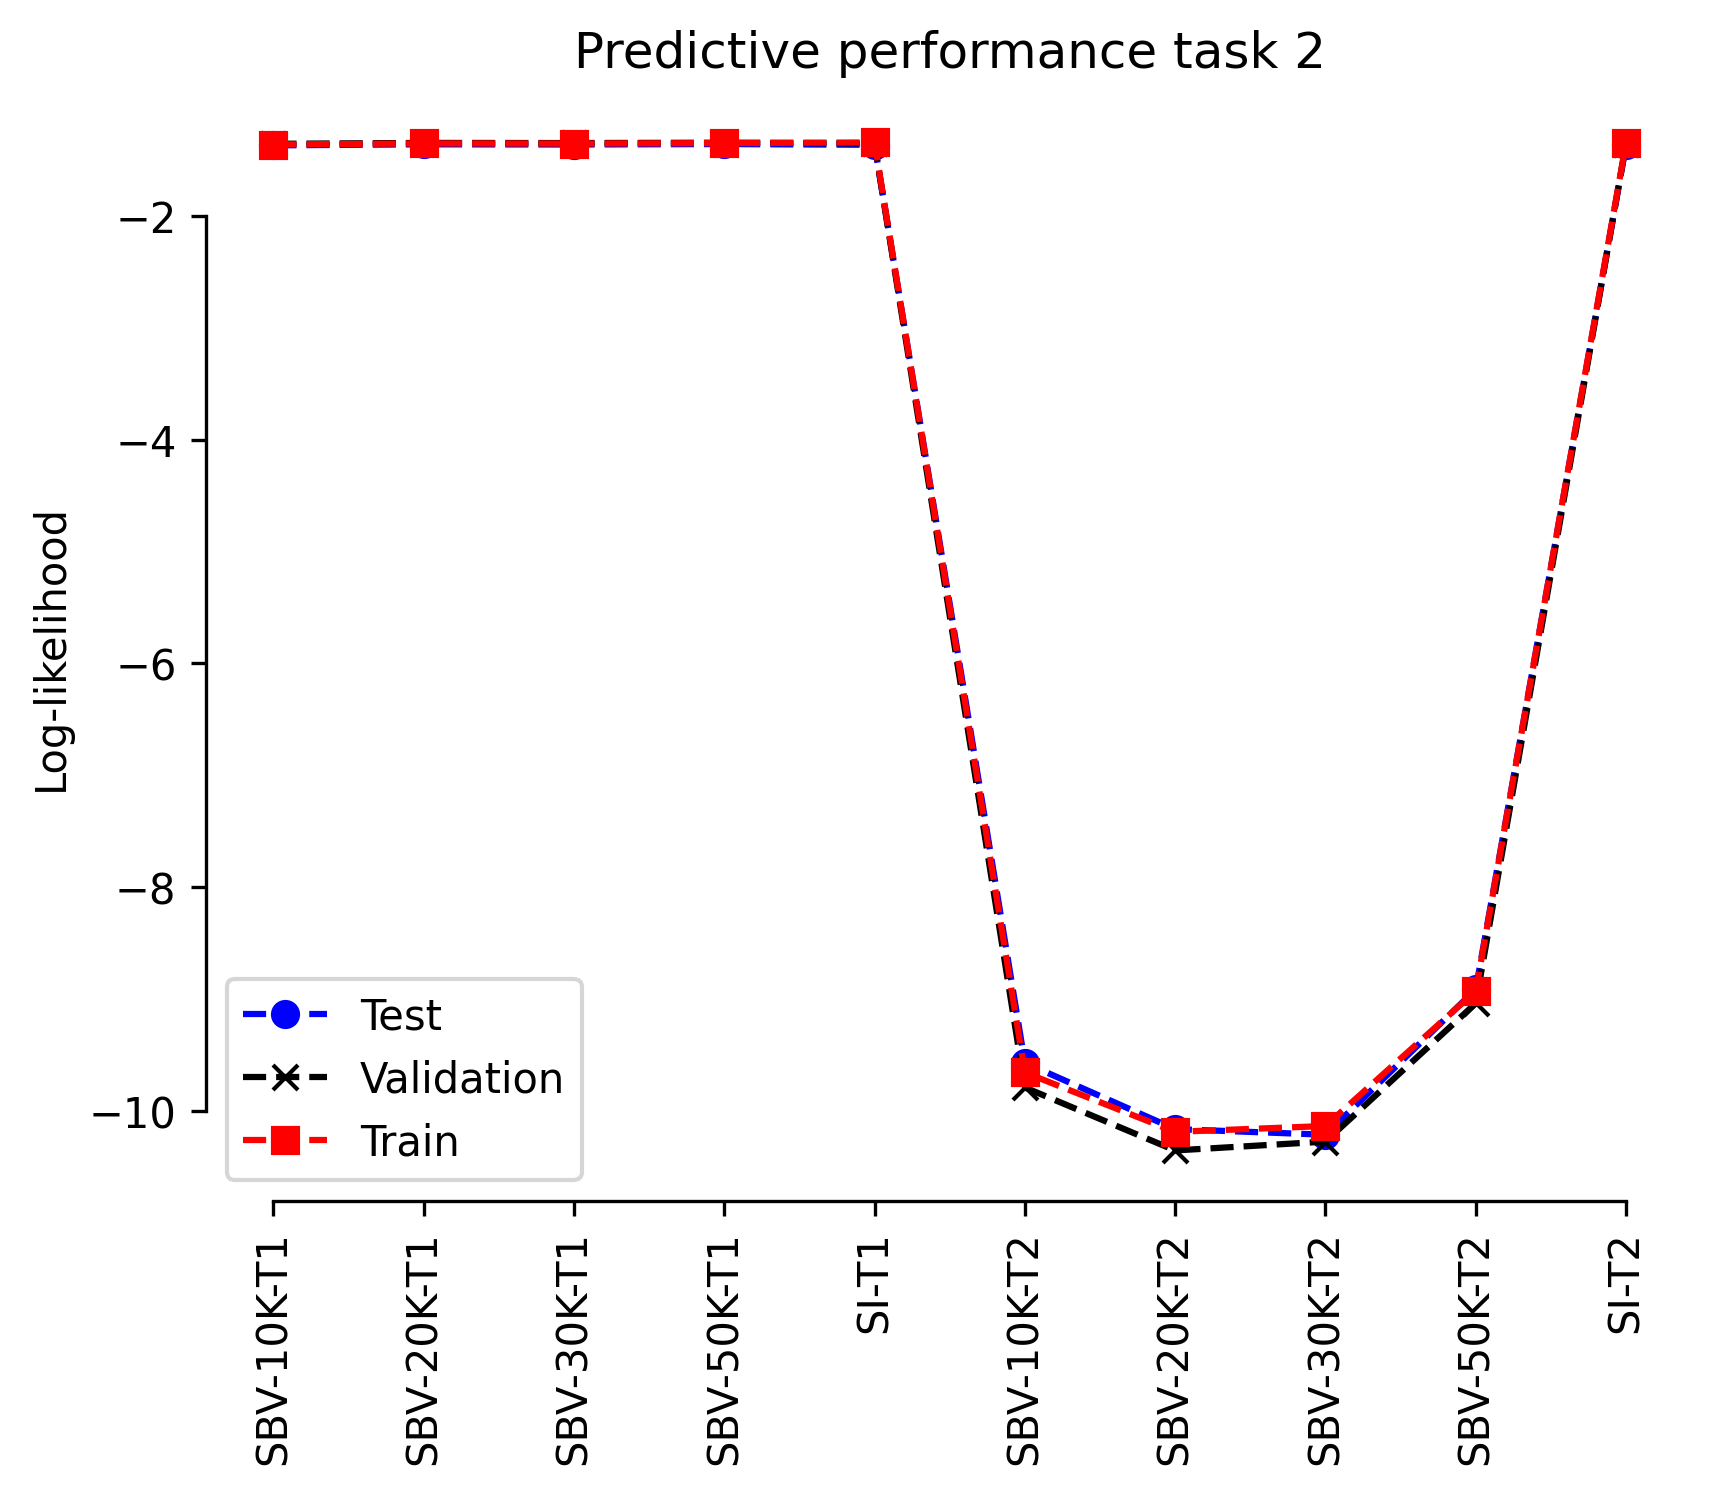

In [11]:
train_metrics_data2 = [
    train_si2_data2,
    train_sbv2_50k_data2,
    train_sbv2_30k_data2,
    train_sbv2_20k_data2,
    train_sbv2_10k_data2,
    train_si1_data2,
    train_sbv1_50k_data2,
    train_sbv1_30k_data2,
    train_sbv1_20k_data2,
    train_sbv1_10k_data2,
    # train_sbv2_prior_data2,
]

val_metrics_data2 = [
    val_si2_data2,
    val_sbv2_50k_data2,
    val_sbv2_30k_data2,
    val_sbv2_20k_data2,
    val_sbv2_10k_data2,
    val_si1_data2,
    val_sbv1_50k_data2,
    val_sbv1_30k_data2,
    val_sbv1_20k_data2,
    val_sbv1_10k_data2,
    # val_sbv2_prior_data2,
]

test_metrics_data2 = [
    test_si2_data2,
    test_sbv2_50k_data2,
    test_sbv2_30k_data2,
    test_sbv2_20k_data2,
    test_sbv2_10k_data2,
    test_si1_data2,
    test_sbv1_50k_data2,
    test_sbv1_30k_data2,
    test_sbv1_20k_data2,
    test_sbv1_10k_data2,
    # test_sbv2_prior_data2,
]

# Update the x-axis labels
x = [
    "SI-T2",
    "SBV-50K-T2",
    "SBV-30K-T2",
    "SBV-20K-T2",
    "SBV-10K-T2",
    "SI-T1",
    "SBV-50K-T1",
    "SBV-30K-T1",
    "SBV-20K-T1",
    "SBV-10K-T1",
    # "Prior-T2",
]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1],
    test_metrics_data2[::-1],
    color="blue",
    marker="o",
    linestyle="--",
    label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data2[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1],
    train_metrics_data2[::-1],
    color="red",
    marker="s",
    linestyle="--",
    label="Train",
)
sns.despine(ax=ax, trim=True)
# rotate the x-axis labels
plt.xticks(rotation=90)
ax.set_ylabel("Log-likelihood")
ax.set_title("Predictive performance task 2")
ax.legend()
plt.show()

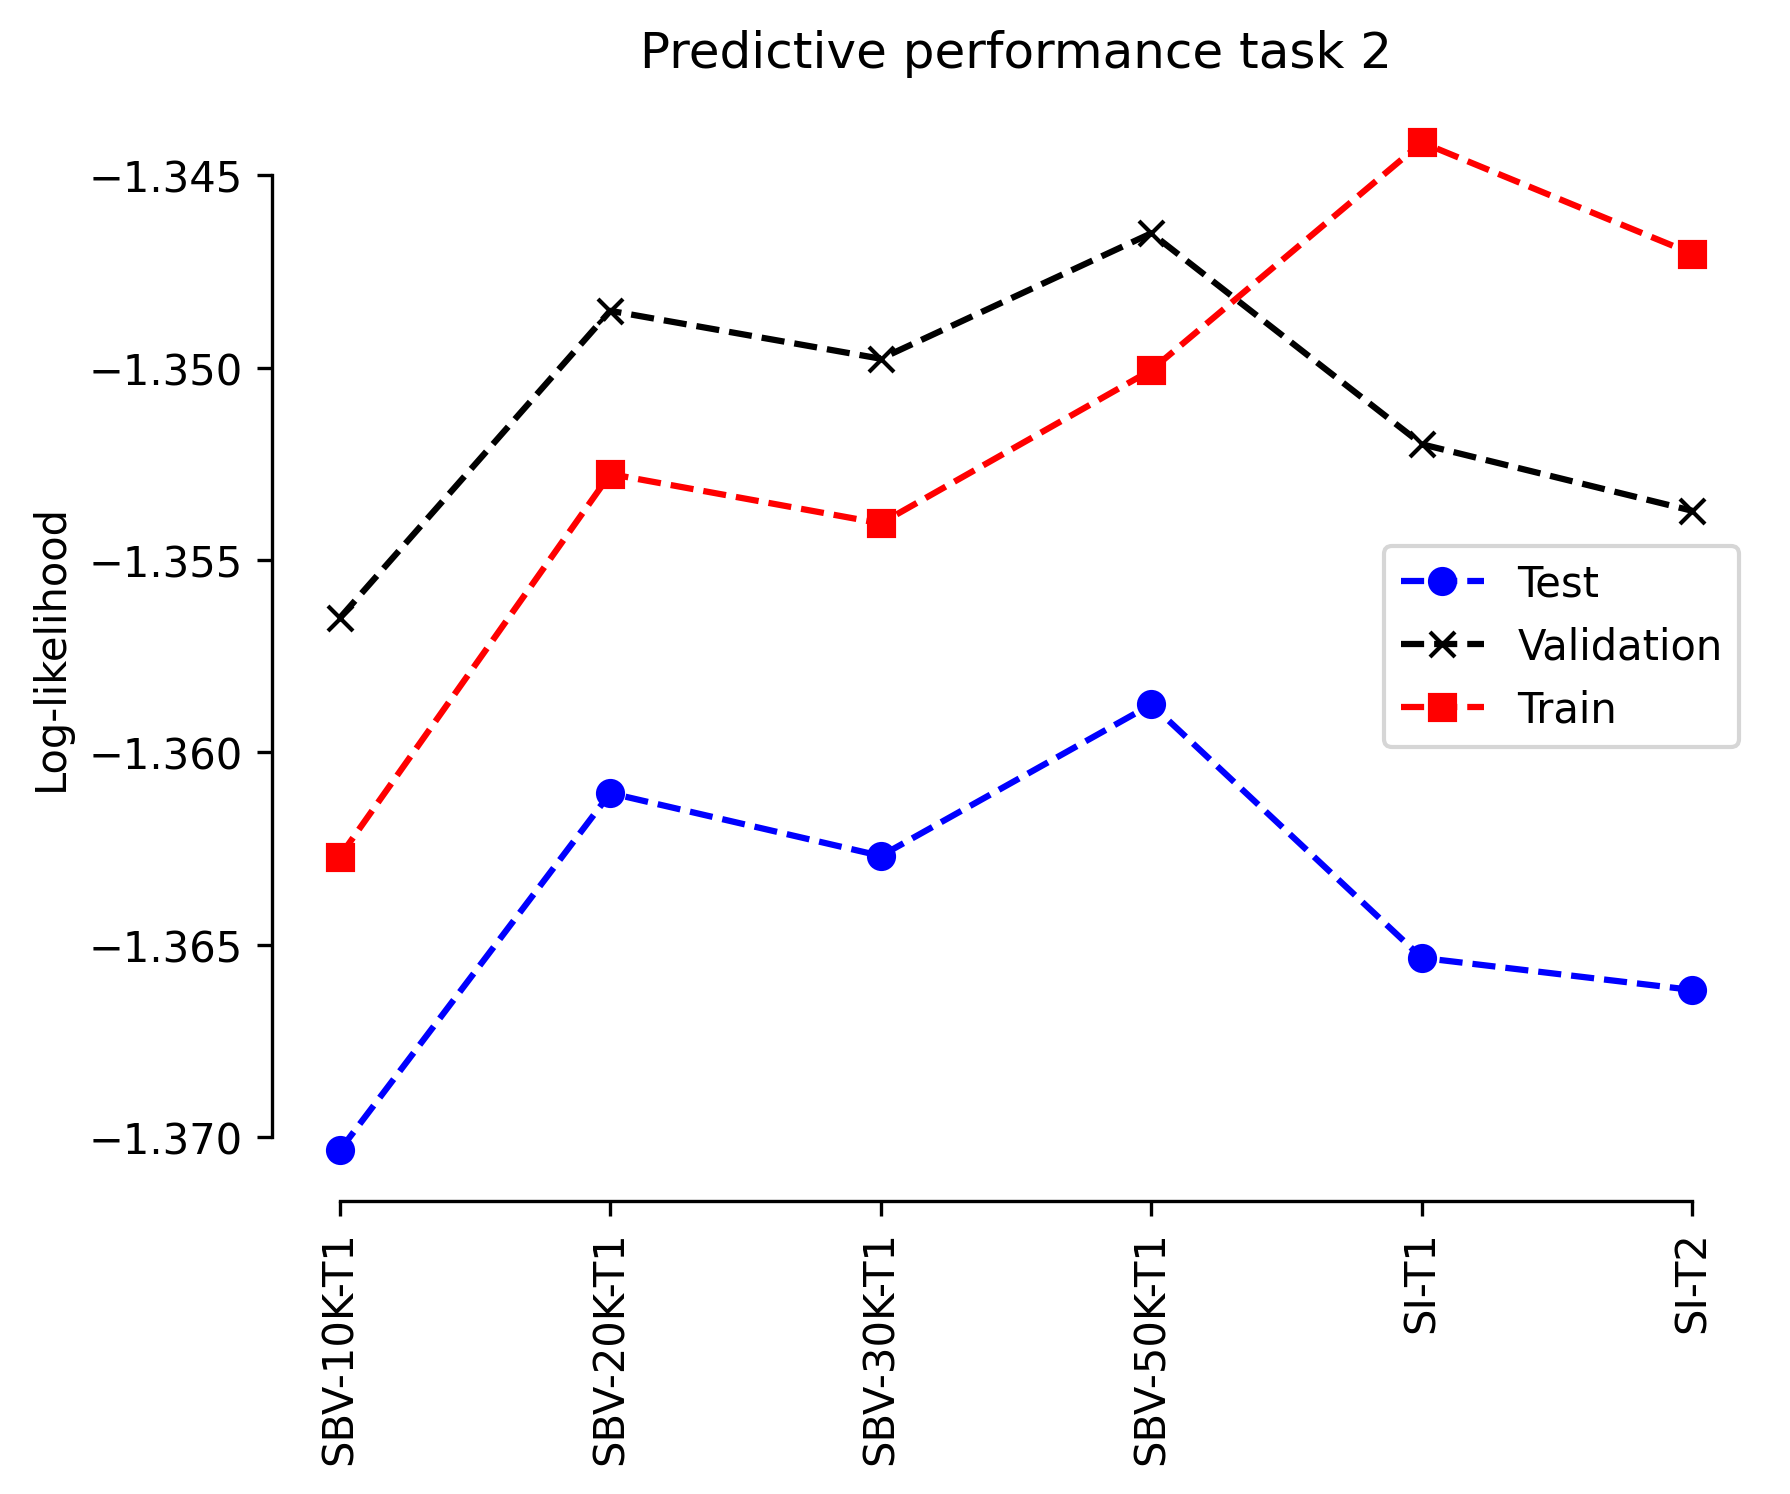

In [13]:
train_metrics_data2 = [
    train_si2_data2,
    # train_sbv2_50k_data2,
    # train_sbv2_30k_data2,
    # train_sbv2_20k_data2,
    # train_sbv2_10k_data2,
    train_si1_data2,
    train_sbv1_50k_data2,
    train_sbv1_30k_data2,
    train_sbv1_20k_data2,
    train_sbv1_10k_data2,
    # train_sbv2_prior_data2,
]

val_metrics_data2 = [
    val_si2_data2,
    # val_sbv2_50k_data2,
    # val_sbv2_30k_data2,
    # val_sbv2_20k_data2,
    # val_sbv2_10k_data2,
    val_si1_data2,
    val_sbv1_50k_data2,
    val_sbv1_30k_data2,
    val_sbv1_20k_data2,
    val_sbv1_10k_data2,
    # val_sbv2_prior_data2,
]

test_metrics_data2 = [
    test_si2_data2,
    # test_sbv2_50k_data2,
    # test_sbv2_30k_data2,
    # test_sbv2_20k_data2,
    # test_sbv2_10k_data2,
    test_si1_data2,
    test_sbv1_50k_data2,
    test_sbv1_30k_data2,
    test_sbv1_20k_data2,
    test_sbv1_10k_data2,
    # test_sbv2_prior_data2,
]

# Update the x-axis labels
x = [
    "SI-T2",
    # "SBV-50K-T2",
    # "SBV-30K-T2",
    # "SBV-20K-T2",
    # "SBV-10K-T2",
    "SI-T1",
    "SBV-50K-T1",
    "SBV-30K-T1",
    "SBV-20K-T1",
    "SBV-10K-T1",
    # "Prior-T2",
]

# Plot the test log-likelihoods with updated models
fig, ax = plt.subplots(dpi=300)
ax.plot(
    x[::-1],
    test_metrics_data2[::-1],
    color="blue",
    marker="o",
    linestyle="--",
    label="Test",
)
ax.plot(
    x[::-1],
    val_metrics_data2[::-1],
    color="black",
    marker="x",
    linestyle="--",
    label="Validation",
)
ax.plot(
    x[::-1],
    train_metrics_data2[::-1],
    color="red",
    marker="s",
    linestyle="--",
    label="Train",
)
sns.despine(ax=ax, trim=True)
# rotate the x-axis labels
plt.xticks(rotation=90)
ax.set_ylabel("Log-likelihood")
ax.set_title("Predictive performance task 2")
ax.legend()
plt.show()